# Welcome to Colab!

## Google Colab is available in VS Code!
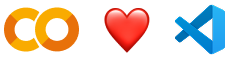

Try the new [Google Colab extension](https://marketplace.visualstudio.com/items?itemName=Google.colab) for Visual Studio Code. You can get up and running in just a few clicks:

*  In VS Code, open the ***Extensions*** view and search for 'Google Colab' to install.
*  Open the kernel selector by creating or opening any `.ipynb` notebook file in your local workspace and either running a cell or clicking the ***Select Kernel*** button in the top right.
*  Click ***Colab*** and then select your desired runtime, sign in with your Google account, and you're all set!

See more details in our [announcement blog here](https://developers.googleblog.com/google-colab-is-coming-to-vs-code).

## 🎁 Free Pro Plan for Gemini & Colab for US College Students 🎓

Get more access to our most accurate model Gemini 3 Pro for advanced coding, complex research, and innovative projects, backed by Colab’s dedicated high-compute resources for data science and machine learning.

Get the Gemini free offer at [gemini.google/students](https://gemini.google/students?utm_source=colab&utm_medium=banner&utm_campaign=students_xpa_us-colab-banner).  
Get the Colab free offer at [colab.research.google.com/signup](https://colab.research.google.com/signup).  
Terms Apply.

## Access popular AI models via Google-Colab-AI Without an API Key
All users have access to most popular LLMs via the `google-colab-ai` Python library, and paid users have access to a wider selection of models. For more details, refer to the [getting started with google colab ai](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb).



You can import your own data into Colab notebooks from your Google Drive account, including from spreadsheets, as well as from Github and many other sources. To learn more about importing data, and how Colab can be used for data science, see the links below under [Working with Data](#working-with-data).

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

In [30]:
df = pd.read_csv("AAPL.csv")
print(df.head())


         Date   Price    Open    High     Low     Vol. Change %
0  03/27/2024  173.31  170.30  173.58  170.14   59.11M    2.12%
1  03/26/2024  169.71  170.01  171.41  169.65   57.22M   -0.67%
2  03/25/2024  170.85  170.37  171.94  169.46   54.21M   -0.83%
3  03/22/2024  172.28  171.76  173.05  170.06   71.16M    0.53%
4  03/21/2024  171.37  177.05  177.49  170.84  106.18M   -4.09%


In [31]:
print(df.info()),

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10912 entries, 0 to 10911
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      10912 non-null  object 
 1   Price     10912 non-null  float64
 2   Open      10912 non-null  float64
 3   High      10912 non-null  float64
 4   Low       10912 non-null  float64
 5   Vol.      10911 non-null  object 
 6   Change %  10912 non-null  object 
dtypes: float64(4), object(3)
memory usage: 596.9+ KB
None


(None,)

In [32]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
print(df.isnull().sum())


Date        0
Price       0
Open        0
High        0
Low         0
Vol.        1
Change %    0
dtype: int64


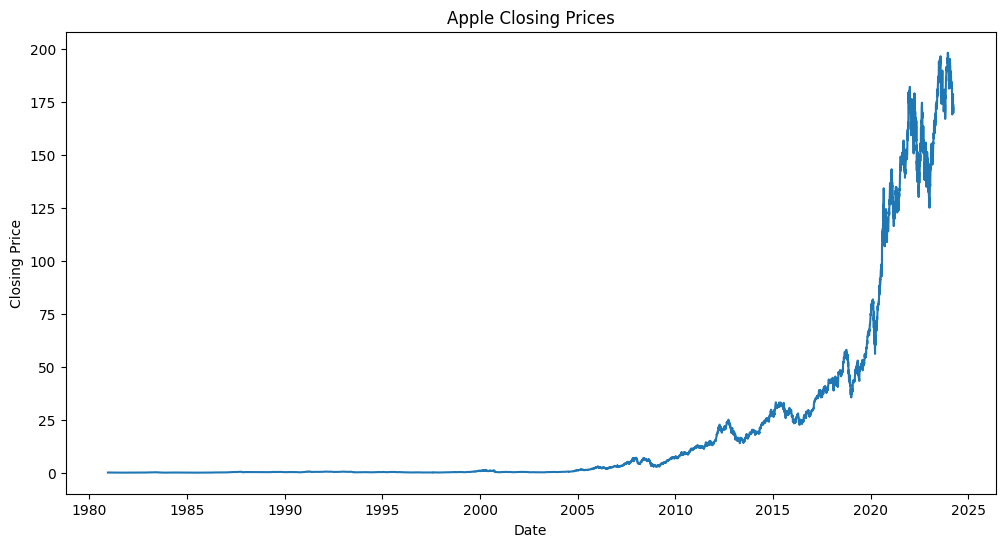

In [33]:
df = df.dropna()
plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Price'])

plt.title('Apple Closing Prices')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.show()

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [35]:
df['Baseline_Prediction'] = df['Price'].shift(1)

In [36]:
baseline_df = df.dropna()

In [37]:
y_true = baseline_df['Price']
y_pred = baseline_df['Baseline_Prediction']

In [38]:
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

In [39]:
print("Baseline MAE:", mae)
print("Baseline RMSE:", rmse)

Baseline MAE: 0.27641246562786437
Baseline RMSE: 0.8560450380914916


In [40]:
from sklearn.preprocessing import MinMaxScaler

In [41]:
data = df[['Price']].values

In [42]:
train_size = int(len(data) * 0.8)

train_data = data[:train_size]
test_data = data[train_size:]

In [43]:
scaler = MinMaxScaler(feature_range=(0,1))

In [44]:
train_scaled = scaler.fit_transform(train_data)

In [45]:
test_scaled = scaler.transform(test_data)

In [46]:
print(train_scaled[:5])
print(test_scaled[:5])

[[0.00240964]
 [0.00210843]
 [0.00180723]
 [0.00210843]
 [0.00210843]]
[[0.93584337]
 [0.92289157]
 [0.92740964]
 [0.9246988 ]
 [0.91987952]]


In [47]:
data = train_scaled
sequence_length = 30

X = []
y = []
for i in range(sequence_length, len(data)):
    X.append(data[i-sequence_length:i])
    y.append(data[i])
X = np.array(X)
y = np.array(y)

In [48]:
X = X.reshape((X.shape[0], X.shape[1], 1))

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8698, 30, 1)
y shape: (8698, 1)


In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(
    units=50,
    return_sequences=True,
    input_shape=(X.shape[1], 1)
))


model.add(Dropout(0.2))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [24]:
model.add(LSTM(units=50))
model.add(Dropout(0.2))
model.add(Dense(units=1))
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [26]:
checkpoint = ModelCheckpoint(
    "best_lstm_model.keras",
    monitor='val_loss',
    save_best_only=True
)

In [27]:
history = model.fit(
    X,
    y,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - loss: 6.2744e-05 - val_loss: 0.0013
Epoch 2/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 2.7893e-05 - val_loss: 0.0061
Epoch 3/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 2.6785e-05 - val_loss: 0.0048
Epoch 4/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 2.0946e-05 - val_loss: 0.0013
Epoch 5/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - loss: 1.9714e-05 - val_loss: 0.0026
Epoch 6/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 17s 67ms/step - loss: 2.0815e-05 - val_loss: 0.0034


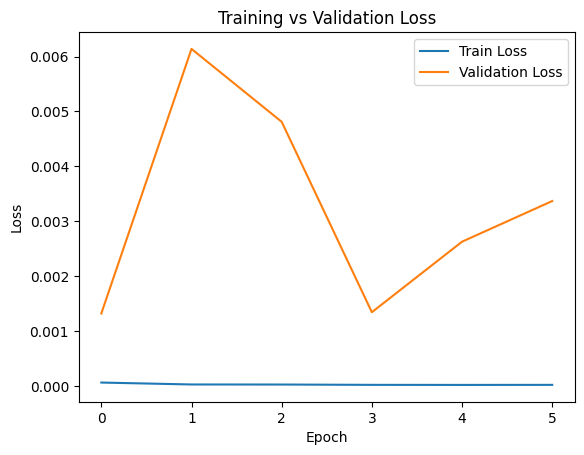

In [28]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Train Loss', 'Validation Loss'])

plt.show()

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

predictions = model.predict(X)

predictions = scaler.inverse_transform(predictions)

actual_prices = scaler.inverse_transform(y)

mae = mean_absolute_error(actual_prices, predictions)

rmse = np.sqrt(mean_squared_error(actual_prices, predictions))

print("LSTM MAE:", mae)
print("LSTM RMSE:", rmse)

272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
LSTM MAE: 0.2280856403758185
LSTM RMSE: 0.549495826038567


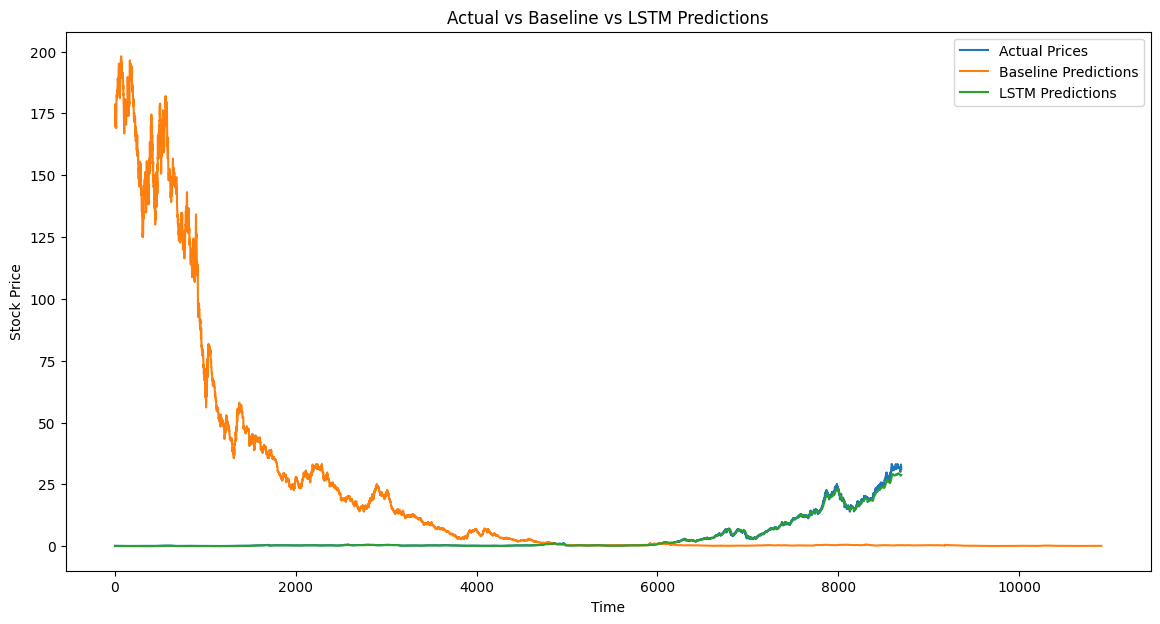

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

plt.plot(actual_prices, label='Actual Prices')

plt.plot(y_pred, label='Baseline Predictions')

plt.plot(predictions, label='LSTM Predictions')

plt.title("Actual vs Baseline vs LSTM Predictions")

plt.xlabel("Time")

plt.ylabel("Stock Price")

plt.legend()

plt.show()